# Machine Learning (CS-324) CEP @ NED UET

**Binary Classification Models - Identifying Cats and Dogs.**




---
Group Members:
* CS-23101 Somaan Abbasi
* CS-23126 Hamza Sheikh
* CS-23127 Ammar Ahmed
* CS-23099 Zain Rajput


(kindly note that we are retrieving the dataset from github, manual insertion is not required)

In [ ]:
import requests

url = "https://github.com/SomaanAbbasi/Binary-Classification-CEP/raw/refs/heads/main/dataset.zip"
r = requests.get(url)
with open("dataset.zip", "wb") as f:
    f.write(r.content)

(if manual insertion of the dataset is to be used: comment out the above code cell, then un-comment the below cell. make sure dataset.zip exists in the root directory)

In [ ]:
# import os

# if not os.path.exists('dataset.zip'):
#     try:
#         from google.colab import files
#         uploaded = files.upload()
#         if len(uploaded) > 0 and 'dataset.zip' not in uploaded:
#             uploaded_name = list(uploaded.keys())[0]
#             if uploaded_name.endswith('.zip'):
#                 os.rename(uploaded_name, 'dataset.zip')
#     except ModuleNotFoundError:
#         print("Local Jupyter detected. Please drop 'dataset.zip' into this notebook's directory.")

In [ ]:
import zipfile
import os

# Unzip the downloaded file
with zipfile.ZipFile("dataset.zip", "r") as zip_ref:
    zip_ref.extractall("raw_data")

# Verification check
print(f"Total Cats: {len(os.listdir('raw_data/cat'))}")
print(f"Total Dogs: {len(os.listdir('raw_data/dog'))}")

Total Cats: 888
Total Dogs: 929


Splitting the dataset (80/10/10 split)

In [ ]:
!pip install split-folders
import splitfolders

# This will create 'dataset_final' with train, val, and test sub-folders
splitfolders.ratio("raw_data", output="dataset_final",
                   seed=1337, ratio=(.8, .1, .1))

Copying files: 1817 files [00:00, 8144.29 files/s]


Loading the Data for the model

In [ ]:
import tensorflow as tf

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    "dataset_final/train",
    shuffle=True,
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    "dataset_final/val",
    shuffle=True,
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE
)

# Test set stays unshuffled for a consistent evaluation at the end
test_ds = tf.keras.utils.image_dataset_from_directory(
    "dataset_final/test",
    shuffle=False,
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE
)

Found 1453 files belonging to 2 classes.
Found 180 files belonging to 2 classes.
Found 184 files belonging to 2 classes.


# Model 1.1 Implementing CNN from scratch:

In [ ]:
from tensorflow.keras import layers, models, Input

model_scratch = models.Sequential([
    # Use an explicit Input layer to remove the warning
    Input(shape=(224, 224, 3)),

    layers.Rescaling(1./255),

    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

model_scratch.compile(optimizer='adam',
                      loss='binary_crossentropy',
                      metrics=['accuracy'])

model_scratch.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

Training the model:

In [ ]:
epochs = 20

history = model_scratch.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs
)

Epoch 1/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 18s 179ms/step - accuracy: 0.4811 - loss: 0.7117 - val_accuracy: 0.4889 - val_loss: 0.6931
Epoch 2/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - accuracy: 0.5286 - loss: 0.6928 - val_accuracy: 0.6167 - val_loss: 0.6757
Epoch 3/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - accuracy: 0.5795 - loss: 0.6782 - val_accuracy: 0.6056 - val_loss: 0.6601
Epoch 4/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - accuracy: 0.6435 - loss: 0.6347 - val_accuracy: 0.5944 - val_loss: 0.6700
Epoch 5/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - accuracy: 0.7006 - loss: 0.5724 - val_accuracy: 0.5889 - val_loss: 0.7013
Epoch 6/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - accuracy: 0.7729 - loss: 0.4625 - val_accuracy: 0.6111 - val_loss: 0.7292
Epoch 7/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - accuracy: 0.8582 - loss: 0.3265 - val_accuracy: 0.6000 - val_loss: 1.0056
Epoch 8/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - accuracy: 0.9140 - loss: 0.2127 - val_accuracy: 0.6111 -

Visualising the models performance:

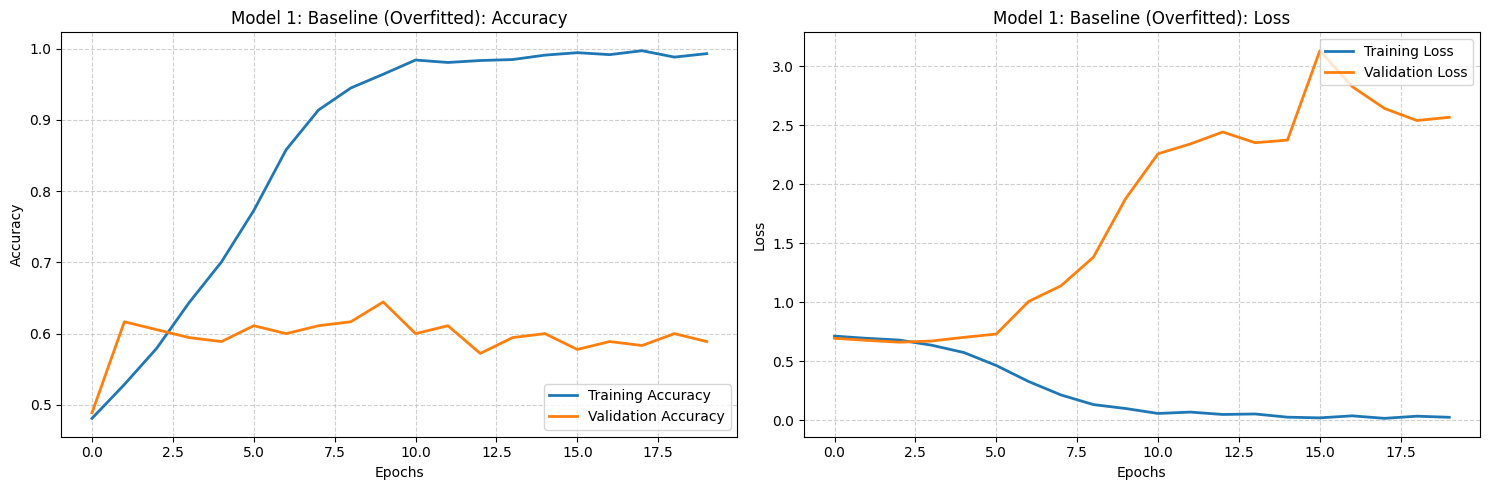

In [ ]:
import matplotlib.pyplot as plt

def plot_results(history, title):
    """
    Plots the training and validation accuracy and loss.
    """
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(15, 5))

    # Plot Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy', linewidth=2)
    plt.plot(epochs_range, val_acc, label='Validation Accuracy', linewidth=2)
    plt.title(f'{title}: Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend(loc='lower right')
    plt.grid(True, linestyle='--', alpha=0.6)

    # Plot Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss', linewidth=2)
    plt.plot(epochs_range, val_loss, label='Validation Loss', linewidth=2)
    plt.title(f'{title}: Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend(loc='upper right')
    plt.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()


plot_results(history, "Model 1: Baseline (Overfitted)")

as we can see, the model is severely overfitted. Time to improve it.

# Model 1.2: From-Scratch CNN with Augmentation

In [ ]:
from tensorflow.keras import layers, models, Input, callbacks
import matplotlib.pyplot as plt

# 1. Define Data Augmentation (Prevents memorization)
data_augmentation = models.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

# 2. Re-build the architecture with Augmentation & Dropout
model_improved = models.Sequential([
    Input(shape=(224, 224, 3)),
    data_augmentation,          # The "Anti-Overfitting" layer
    layers.Rescaling(1./255),

    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5), # Randomly shuts off 50% of neurons to prevent co-dependency
    layers.Dense(1, activation='sigmoid')
])

model_improved.compile(optimizer='adam',
                      loss='binary_crossentropy',
                      metrics=['accuracy'])

# 3. Early Stopping (Crucial for your marks on "Investigation")
# This stops training if validation loss doesn't improve for 5 epochs
early_stop = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)



In [ ]:
# 4. Train the newer model
print("Starting Training for Improved Model...")
history_improved = model_improved.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=[early_stop]
)

Starting Training for Improved Model...
Epoch 1/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 9s 74ms/step - accuracy: 0.4976 - loss: 0.7406 - val_accuracy: 0.5778 - val_loss: 0.6930
Epoch 2/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 3s 63ms/step - accuracy: 0.5251 - loss: 0.6930 - val_accuracy: 0.5500 - val_loss: 0.6874
Epoch 3/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - accuracy: 0.5430 - loss: 0.6916 - val_accuracy: 0.4889 - val_loss: 0.6904
Epoch 4/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - accuracy: 0.5478 - loss: 0.6849 - val_accuracy: 0.5333 - val_loss: 0.6855
Epoch 5/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - accuracy: 0.5169 - loss: 0.6887 - val_accuracy: 0.5611 - val_loss: 0.6816
Epoch 6/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - accuracy: 0.5547 - loss: 0.6842 - val_accuracy: 0.5278 - val_loss: 0.6803
Epoch 7/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 3s 61ms/step - accuracy: 0.5616 - loss: 0.6823 - val_accuracy: 0.5667 - val_loss: 0.6748
Epoch 8/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - accuracy: 0.5451 -

Plot model 1.2

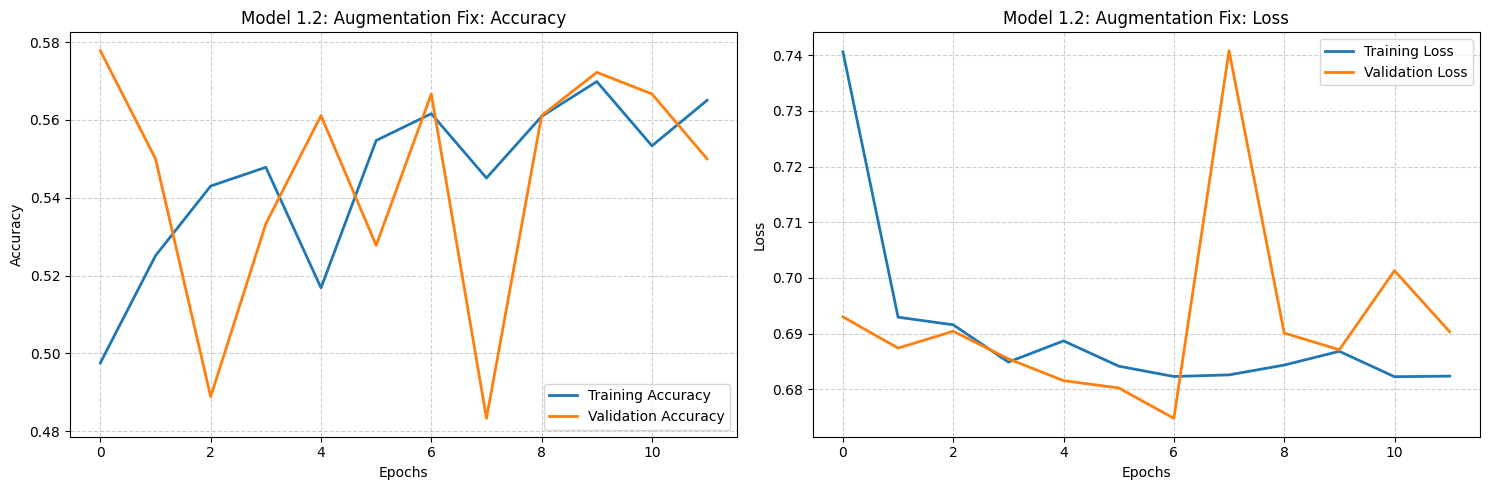

In [ ]:
plot_results(history_improved, "Model 1.2: Augmentation Fix")

now training and validation accuracy are closer to each other, but overall accuracy is still pretty low.

Third and final attempt to improve the from-scratch CNN model:

# Model 1.3: From-Scratch CNN Optimized (Batch Normalization & Low Learning Rate)

In [ ]:
from tensorflow.keras import layers, models, Input, callbacks, optimizers

model_v3 = models.Sequential([
    Input(shape=(224, 224, 3)),
    data_augmentation,
    layers.Rescaling(1./255),

    # Block 1
    layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(), # Stabilizes the learning process
    layers.MaxPooling2D((2, 2)),

    # Block 2
    layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Block 3
    layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Block 4 (Adding more depth)
    layers.Conv2D(256, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(256, activation='relu'), # Increased density
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

# Using a smaller Learning Rate (0.0001 instead of 0.001)
# This forces the model to take "smaller steps" to find the best solution.
model_v3.compile(
    optimizer=optimizers.Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

early_stop_v3 = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=8, # Being a bit more patient this time
    restore_best_weights=True
)



In [ ]:
#train the 3rd model
history_v3 = model_v3.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=[early_stop_v3]
)

Epoch 1/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 14s 159ms/step - accuracy: 0.5526 - loss: 1.0983 - val_accuracy: 0.4889 - val_loss: 0.9255
Epoch 2/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 6s 133ms/step - accuracy: 0.6015 - loss: 0.8380 - val_accuracy: 0.4889 - val_loss: 0.8624
Epoch 3/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 6s 134ms/step - accuracy: 0.6215 - loss: 0.7911 - val_accuracy: 0.4889 - val_loss: 1.1307
Epoch 4/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 6s 134ms/step - accuracy: 0.6401 - loss: 0.7457 - val_accuracy: 0.4944 - val_loss: 0.7804
Epoch 5/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 6s 135ms/step - accuracy: 0.6635 - loss: 0.7112 - val_accuracy: 0.5722 - val_loss: 0.7430
Epoch 6/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 6s 132ms/step - accuracy: 0.6297 - loss: 0.7533 - val_accuracy: 0.5000 - val_loss: 0.8630
Epoch 7/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 6s 134ms/step - accuracy: 0.6855 - loss: 0.6726 - val_accuracy: 0.5667 - val_loss: 0.8629
Epoch 8/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 6s 132ms/step - accuracy: 0.6820 - loss: 0.6823 - val_accuracy: 0

Visualising model 1.3:

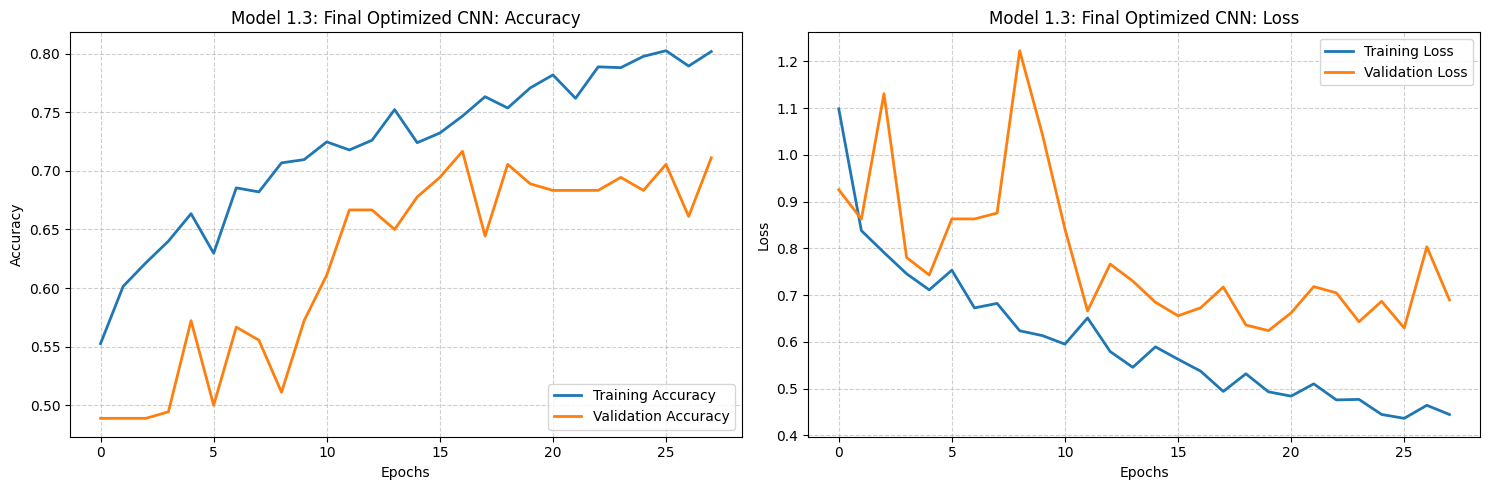

In [ ]:
plot_results(history_v3, "Model 1.3: Final Optimized CNN")

Our from-scratch CNN has achieved close to 70% accuracy as seen above.

# Section 2: Transfer Learning Models with VGG16

# Model 2.1: VGG16 Transfer Learning Baseline (Adam & 256 Units)

In [ ]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras import models, layers, Input

# 1. Load the pre-trained VGG16 model (without the top classification layer)
vgg_base = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# 2. Freeze the base layers so they aren't updated during training
vgg_base.trainable = False

# 3. Build the Transfer Learning model
model_vgg = models.Sequential([
    vgg_base,
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

model_vgg.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_vgg.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,137,729 (80.63 MB)

 Trainable params: 6,423,041 (24.50 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
# We use the same early stopping and datasets as before
history_vgg = model_vgg.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20, # Transfer learning usually converges very quickly
    callbacks=[early_stop] # Re-using the early_stop from previous cells
)

Epoch 1/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 45s 653ms/step - accuracy: 0.7777 - loss: 10.2959 - val_accuracy: 0.9000 - val_loss: 1.3707
Epoch 2/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 9s 201ms/step - accuracy: 0.9312 - loss: 0.4206 - val_accuracy: 0.9278 - val_loss: 0.3143
Epoch 3/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 9s 198ms/step - accuracy: 0.9711 - loss: 0.0795 - val_accuracy: 0.9333 - val_loss: 0.2449
Epoch 4/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 9s 198ms/step - accuracy: 0.9787 - loss: 0.0559 - val_accuracy: 0.9500 - val_loss: 0.2408
Epoch 5/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 10s 199ms/step - accuracy: 0.9862 - loss: 0.0569 - val_accuracy: 0.9444 - val_loss: 0.2112
Epoch 6/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 9s 200ms/step - accuracy: 0.9869 - loss: 0.0355 - val_accuracy: 0.9389 - val_loss: 0.2367
Epoch 7/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 9s 201ms/step - accuracy: 0.9855 - loss: 0.0305 - val_accuracy: 0.9333 - val_loss: 0.2612
Epoch 8/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 9s 203ms/step - accuracy: 0.9890 - loss: 0.0331 - val_accuracy:

plotting the results from the transfer learned VGG model 2.1



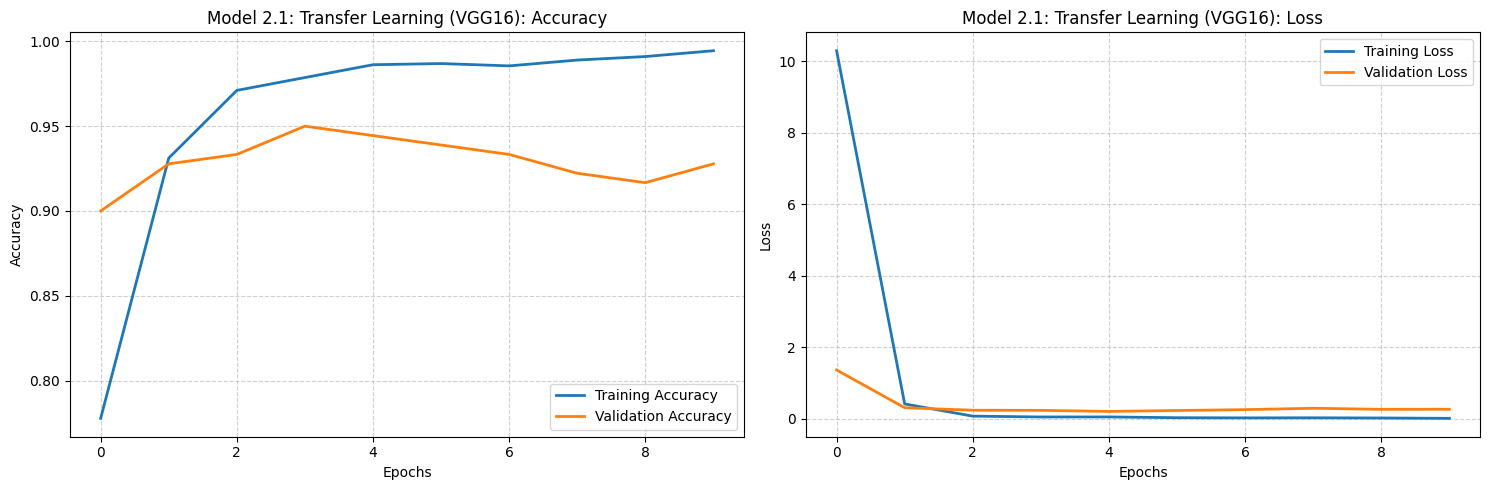

In [ ]:
plot_results(history_vgg, "Model 2.1: Transfer Learning (VGG16)")

# Model 2.2 VGG16 with SGD optimizer


In [ ]:
from tensorflow.keras.optimizers import SGD

# Re-use the same VGG base
model_vgg_v2 = models.Sequential([
    vgg_base, # Already frozen from your previous cell
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

# Change Hyperparameter: Optimizer (SGD)
model_vgg_v2.compile(
    optimizer=SGD(learning_rate=0.001, momentum=0.9),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_vgg_v2 = model_vgg_v2.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=[early_stop]
)



Epoch 1/15
46/46 ━━━━━━━━━━━━━━━━━━━━ 14s 254ms/step - accuracy: 0.7977 - loss: 5.9422 - val_accuracy: 0.8833 - val_loss: 0.5441
Epoch 2/15
46/46 ━━━━━━━━━━━━━━━━━━━━ 9s 198ms/step - accuracy: 0.8975 - loss: 0.7039 - val_accuracy: 0.9000 - val_loss: 0.3596
Epoch 3/15
46/46 ━━━━━━━━━━━━━━━━━━━━ 9s 201ms/step - accuracy: 0.8995 - loss: 0.3994 - val_accuracy: 0.9056 - val_loss: 0.2453
Epoch 4/15
46/46 ━━━━━━━━━━━━━━━━━━━━ 9s 202ms/step - accuracy: 0.9270 - loss: 0.2717 - val_accuracy: 0.8833 - val_loss: 0.2961
Epoch 5/15
46/46 ━━━━━━━━━━━━━━━━━━━━ 9s 202ms/step - accuracy: 0.9408 - loss: 0.1388 - val_accuracy: 0.9056 - val_loss: 0.2913


Visualizing Model 2.2:

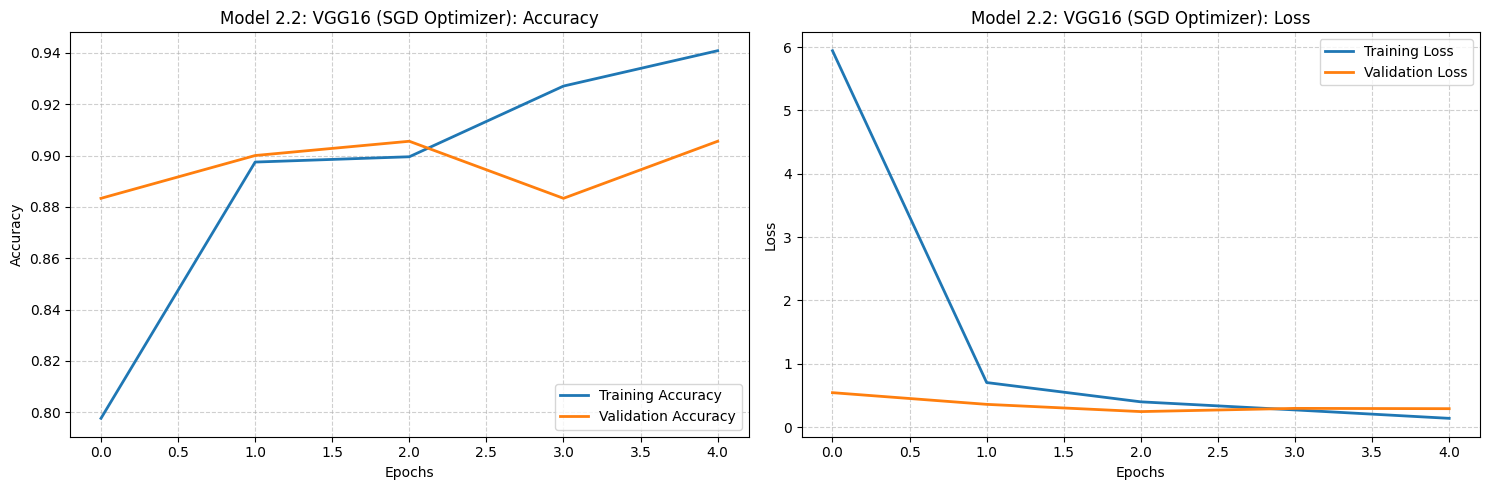

In [ ]:
plot_results(history_vgg_v2, "Model 2.2: VGG16 (SGD Optimizer)")

# Model 2.3: VGG16 with Reduced Complexity (64 Units)
Reduced the number of neurons in the Dense layer from 256 to 64. This tests if a "lighter" head is enough for binary classification or if it causes underfitting.

In [ ]:
model_vgg_v3 = models.Sequential([
    vgg_base,
    layers.Flatten(),
    layers.Dense(64, activation='relu'), # Change Hyperparameter: Layer Size
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

model_vgg_v3.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_vgg_v3 = model_vgg_v3.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=[early_stop]
)



Epoch 1/15
46/46 ━━━━━━━━━━━━━━━━━━━━ 16s 269ms/step - accuracy: 0.7502 - loss: 3.1529 - val_accuracy: 0.8556 - val_loss: 0.3200
Epoch 2/15
46/46 ━━━━━━━━━━━━━━━━━━━━ 9s 199ms/step - accuracy: 0.8341 - loss: 0.3084 - val_accuracy: 0.9167 - val_loss: 0.1941
Epoch 3/15
46/46 ━━━━━━━━━━━━━━━━━━━━ 9s 203ms/step - accuracy: 0.8637 - loss: 0.2543 - val_accuracy: 0.9167 - val_loss: 0.1907
Epoch 4/15
46/46 ━━━━━━━━━━━━━━━━━━━━ 9s 203ms/step - accuracy: 0.8754 - loss: 0.2384 - val_accuracy: 0.9056 - val_loss: 0.1687
Epoch 5/15
46/46 ━━━━━━━━━━━━━━━━━━━━ 9s 204ms/step - accuracy: 0.8961 - loss: 0.1639 - val_accuracy: 0.9444 - val_loss: 0.1333
Epoch 6/15
46/46 ━━━━━━━━━━━━━━━━━━━━ 9s 200ms/step - accuracy: 0.9105 - loss: 0.1714 - val_accuracy: 0.9222 - val_loss: 0.1449
Epoch 7/15
46/46 ━━━━━━━━━━━━━━━━━━━━ 9s 199ms/step - accuracy: 0.9209 - loss: 0.1477 - val_accuracy: 0.9222 - val_loss: 0.2051
Epoch 8/15
46/46 ━━━━━━━━━━━━━━━━━━━━ 9s 198ms/step - accuracy: 0.9250 - loss: 0.1437 - val_accuracy: 0

Visualizing Model 2.3:

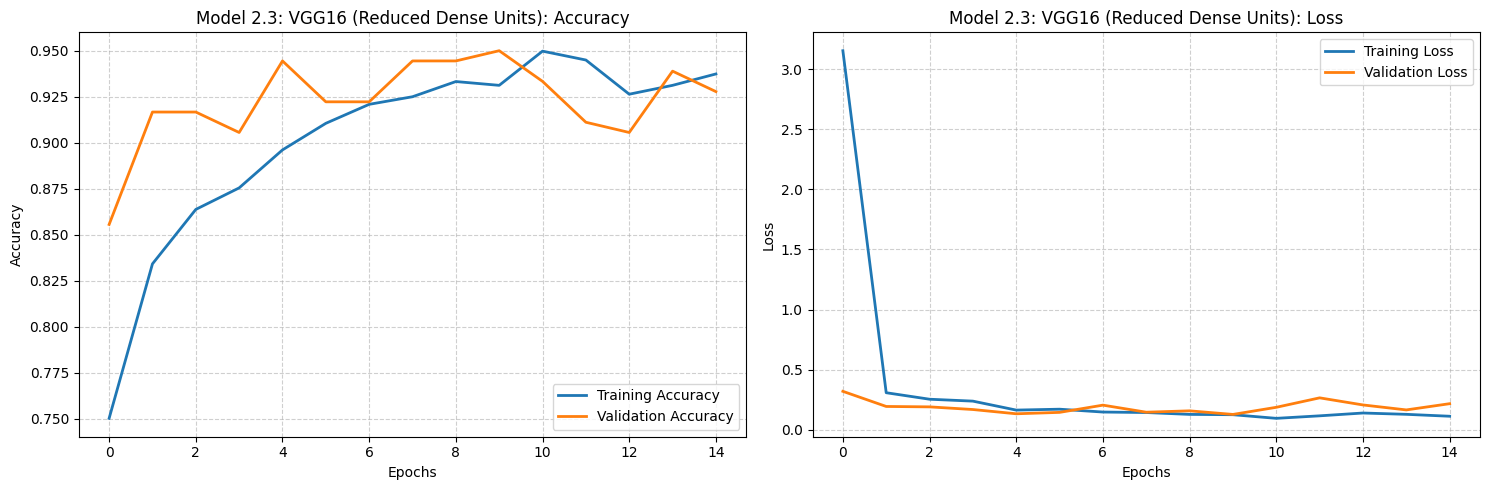

In [ ]:
plot_results(history_vgg_v3, "Model 2.3: VGG16 (Reduced Dense Units)")

# Section 3: Transfer Learning Models with MobileNetV2

# Model 3.1: MobileNetV2 Baseline

Since 64 dense units worked best for VGG16, we will start there and test different Dropout rates and Preprocessing variations.

In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

mobilenet_base = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
mobilenet_base.trainable = False

model_mob_v1 = models.Sequential([
    layers.Lambda(preprocess_input, input_shape=(224, 224, 3)),
    mobilenet_base,
    layers.GlobalAveragePooling2D(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')
])

model_mob_v1.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history_mob_v1 = model_mob_v1.fit(train_ds, validation_data=val_ds, epochs=10, callbacks=[early_stop])


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/lambda_layer.py:65: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


46/46 ━━━━━━━━━━━━━━━━━━━━ 49s 669ms/step - accuracy: 0.8885 - loss: 0.2574 - val_accuracy: 0.9722 - val_loss: 0.0832
Epoch 2/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.9511 - loss: 0.1167 - val_accuracy: 0.9833 - val_loss: 0.0696
Epoch 3/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.9608 - loss: 0.1035 - val_accuracy: 0.9889 - val_loss: 0.0591
Epoch 4/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - accuracy: 0.9773 - loss: 0.0721 - val_accuracy: 0.9833 - val_loss: 0.0530
Epoch 5/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.9766 - loss: 0.0552 - val_accuracy: 0.9833 - val_loss: 0.0658
Epoch 6/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.9855 - loss: 0.0432 - val_accuracy: 0.9833 - val_loss: 0.0453
Epoch 7/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.9904 - loss: 0.0287 - val_accuracy: 0.9833 - val_loss: 0.0439
Epoch 8/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.9855 - loss: 0.0317 - val_accuracy: 0.9889 - val_loss: 

Visualizing Model 3.1:

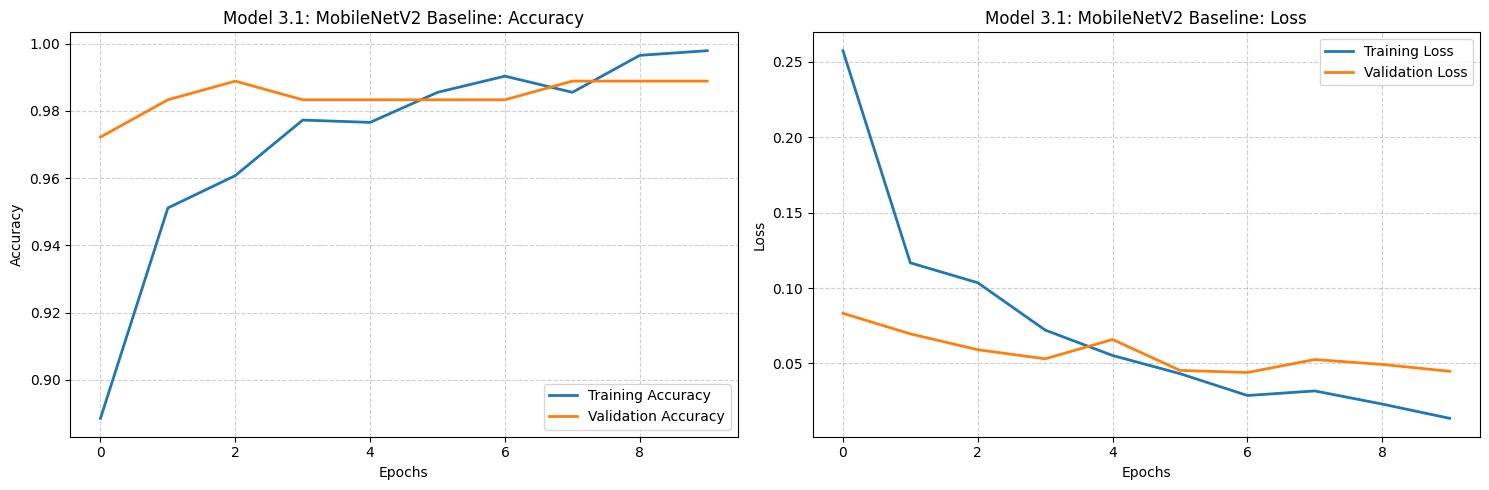

In [ ]:
plot_results(history_mob_v1, "Model 3.1: MobileNetV2 Baseline")

# Model 3.2: MobileNetV2 with High Dropout (0.7)

This tests if even more aggressive regularization helps the model on the dataset.

In [ ]:
model_mob_v2 = models.Sequential([
    layers.Lambda(preprocess_input, input_shape=(224, 224, 3)),
    mobilenet_base,
    layers.GlobalAveragePooling2D(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.7), # Increased Dropout
    layers.Dense(1, activation='sigmoid')
])

model_mob_v2.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history_mob_v2 = model_mob_v2.fit(train_ds, validation_data=val_ds, epochs=10, callbacks=[early_stop])


Epoch 1/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 23s 313ms/step - accuracy: 0.8410 - loss: 0.3795 - val_accuracy: 0.9611 - val_loss: 0.1230
Epoch 2/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.9298 - loss: 0.1890 - val_accuracy: 0.9500 - val_loss: 0.1048
Epoch 3/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.9332 - loss: 0.1549 - val_accuracy: 0.9778 - val_loss: 0.0780
Epoch 4/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.9456 - loss: 0.1334 - val_accuracy: 0.9778 - val_loss: 0.0736
Epoch 5/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.9553 - loss: 0.1178 - val_accuracy: 0.9778 - val_loss: 0.0652


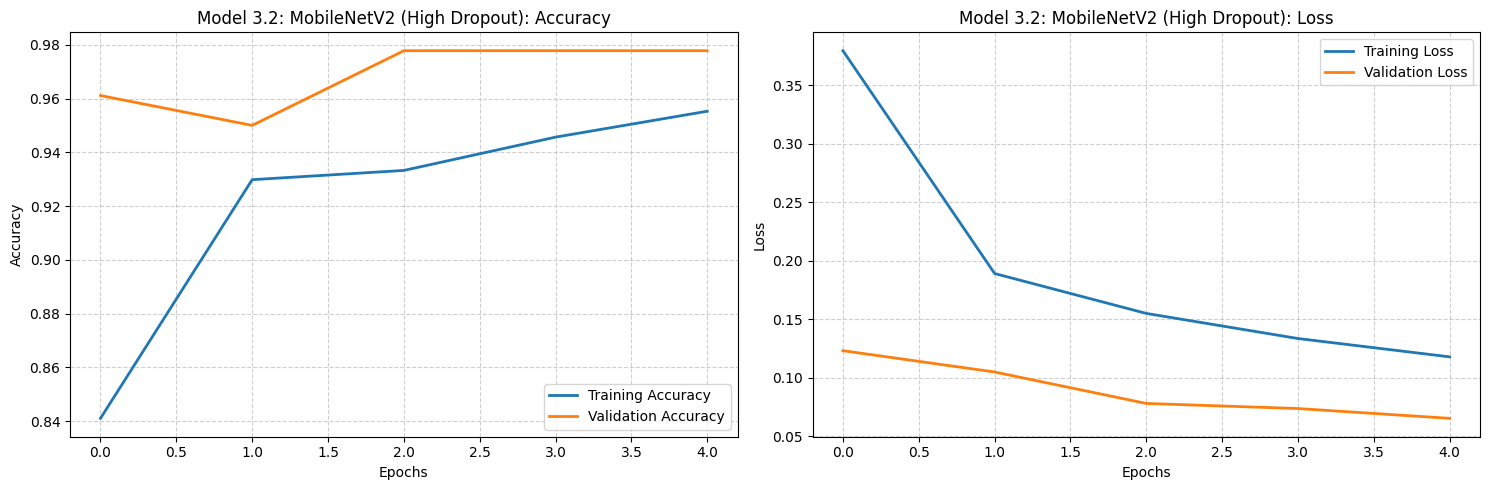

In [ ]:
plot_results(history_mob_v2, "Model 3.2: MobileNetV2 (High Dropout)")

# Model 3.3: MobileNetV2 with Fine-Tuning (Unfrozen)

For the final model, we will "unfreeze" the last few layers of MobileNetV2 to see if letting the model adapt its internal filters to your specific cats and dogs increases accuracy.

In [ ]:
mobilenet_base.trainable = True
# Freeze all layers except the last 20
for layer in mobilenet_base.layers[:-20]:
    layer.trainable = False

model_mob_v3 = models.Sequential([
    layers.Lambda(preprocess_input, input_shape=(224, 224, 3)),
    mobilenet_base,
    layers.GlobalAveragePooling2D(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')
])

model_mob_v3.compile(optimizer=optimizers.Adam(1e-5), loss='binary_crossentropy', metrics=['accuracy'])
history_mob_v3 = model_mob_v3.fit(train_ds, validation_data=val_ds, epochs=10, callbacks=[early_stop])


Epoch 1/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 33s 398ms/step - accuracy: 0.6132 - loss: 0.6829 - val_accuracy: 0.9000 - val_loss: 0.3880
Epoch 2/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.8238 - loss: 0.4355 - val_accuracy: 0.9444 - val_loss: 0.2659
Epoch 3/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - accuracy: 0.8789 - loss: 0.3367 - val_accuracy: 0.9500 - val_loss: 0.2004
Epoch 4/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - accuracy: 0.9036 - loss: 0.2778 - val_accuracy: 0.9500 - val_loss: 0.1640
Epoch 5/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - accuracy: 0.9202 - loss: 0.2305 - val_accuracy: 0.9500 - val_loss: 0.1431


Visualizing Model 3.3:

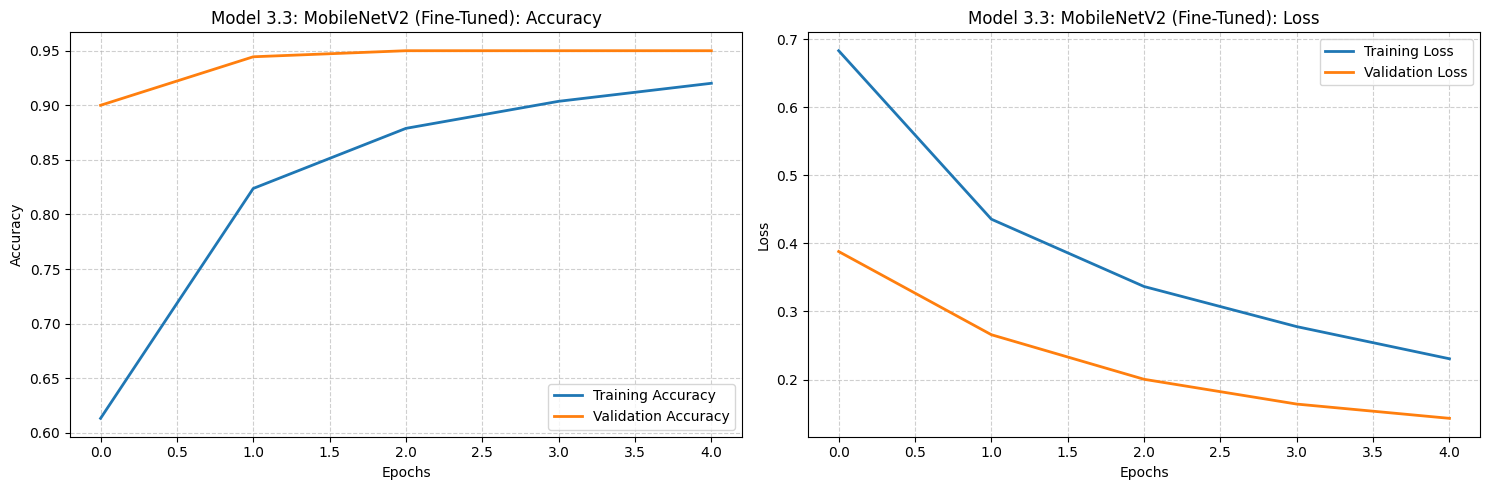

In [ ]:
plot_results(history_mob_v3, "Model 3.3: MobileNetV2 (Fine-Tuned)")

# Section 4: Comparing the 9 models on the Test set

In [ ]:
# 1. Evaluate all models on the Test Set
results = {
    "Model 1.1 (Naive Scratch)": model_scratch.evaluate(test_ds, verbose=0),
    "Model 1.2 (Augmented Scratch)": model_improved.evaluate(test_ds, verbose=0),
    "Model 1.3 (Optimized v3)": model_v3.evaluate(test_ds, verbose=0),
    "Model 2.1 (VGG16 Baseline)": model_vgg.evaluate(test_ds, verbose=0),
    "Model 2.2 (VGG16 SGD)": model_vgg_v2.evaluate(test_ds, verbose=0),
    "Model 2.3 (VGG16 64-Units)": model_vgg_v3.evaluate(test_ds, verbose=0),
    "Model 3.1 (MobileNet Baseline)": model_mob_v1.evaluate(test_ds, verbose=0),
    "Model 3.2 (MobileNet Dropout)": model_mob_v2.evaluate(test_ds, verbose=0),
    "Model 3.3 (MobileNet Fine-Tune)": model_mob_v3.evaluate(test_ds, verbose=0),
}

# 2. Print Comparison Table
print(f"{'Model Name':<35} | {'Test Loss':<10} | {'Test Accuracy':<10}")
print("-" * 65)
for name, metrics in results.items():
    print(f"{name:<35} | {metrics[0]:<10.4f} | {metrics[1]:<10.4f}")

Model Name                          | Test Loss  | Test Accuracy
-----------------------------------------------------------------
Model 1.1 (Naive Scratch)           | 2.7612     | 0.5924    
Model 1.2 (Augmented Scratch)       | 0.6732     | 0.5815    
Model 1.3 (Optimized v3)            | 0.6318     | 0.7228    
Model 2.1 (VGG16 Baseline)          | 0.5903     | 0.8913    
Model 2.2 (VGG16 SGD)               | 1.4707     | 0.8261    
Model 2.3 (VGG16 64-Units)          | 0.3364     | 0.8750    
Model 3.1 (MobileNet Baseline)      | 0.1650     | 0.9402    
Model 3.2 (MobileNet Dropout)       | 0.1517     | 0.9620    
Model 3.3 (MobileNet Fine-Tune)     | 0.4282     | 0.8315    


Visually comparing performance of all 9 models:

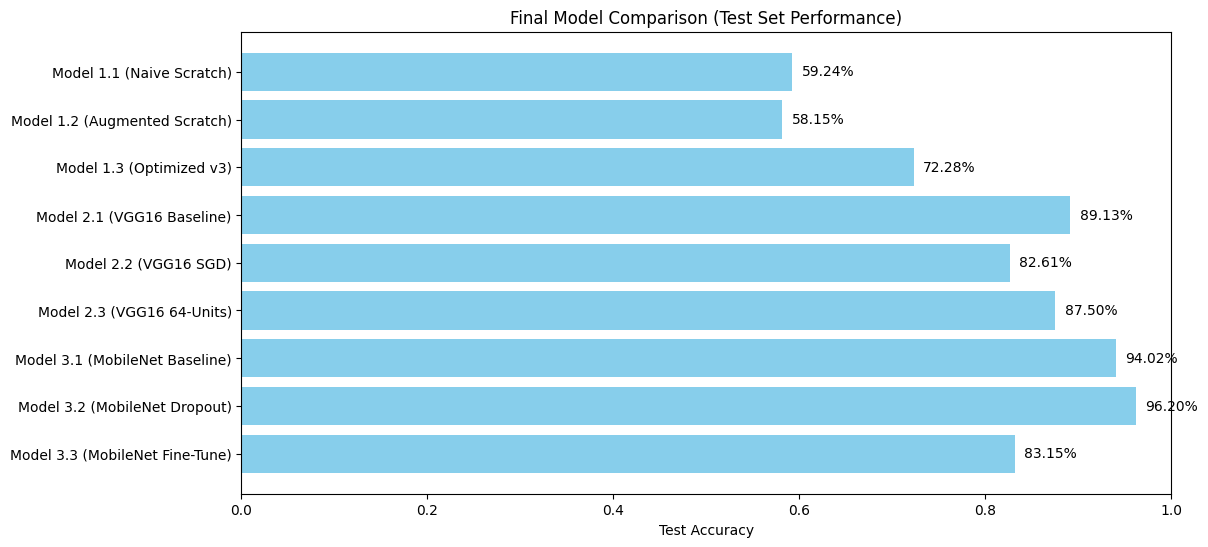

In [ ]:
import matplotlib.pyplot as plt

names = list(results.keys())
accuracies = [metrics[1] for metrics in results.values()]

plt.figure(figsize=(12, 6))
bars = plt.barh(names, accuracies, color='skyblue')
plt.xlabel('Test Accuracy')
plt.title('Final Model Comparison (Test Set Performance)')
plt.xlim(0, 1.0)
plt.gca().invert_yaxis() # Highest accuracy at the top

# Add accuracy labels to the end of bars
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.01, bar.get_y() + bar.get_height()/2, f'{width:.2%}', va='center')

plt.show()

# Section 5: Investigating different split ratios:

# 5.1 Testing a 70/15/15 split for train/valid/test data

In [ ]:
import splitfolders

# Clear existing folder to prevent mixing data
!rm -rf dataset_70_15_15

splitfolders.ratio("raw_data", output="dataset_70_15_15",
                   seed=1337, ratio=(.7, .15, .15))

Copying files: 1817 files [00:00, 7676.68 files/s]


In [ ]:

import tensorflow as tf
from tensorflow.keras import layers, models, Input, optimizers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input


# 1. Data Loaders for the new split
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_ds_70 = tf.keras.utils.image_dataset_from_directory(
    "dataset_70_15_15/train", image_size=IMG_SIZE, batch_size=BATCH_SIZE)
val_ds_15 = tf.keras.utils.image_dataset_from_directory(
    "dataset_70_15_15/val", image_size=IMG_SIZE, batch_size=BATCH_SIZE)
test_ds_15 = tf.keras.utils.image_dataset_from_directory(
    "dataset_70_15_15/test", image_size=IMG_SIZE, batch_size=BATCH_SIZE, shuffle=False)

# 2. Define the Champion Architecture (Model 3.2)
mobilenet_base = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
mobilenet_base.trainable = False

model_70_split = models.Sequential([
    Input(shape=(224, 224, 3)),
    layers.Lambda(preprocess_input),
    mobilenet_base,
    layers.GlobalAveragePooling2D(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.7), # High Dropout as per Model 3.2
    layers.Dense(1, activation='sigmoid')
])

model_70_split.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 3. Train on the 70% data
print("\nTraining on 70/15/15 split...")
history_70 = model_70_split.fit(
    train_ds_70,
    validation_data=val_ds_15,
    epochs=15,
    callbacks=[early_stop],
    verbose=1
)


Found 1271 files belonging to 2 classes.
Found 272 files belonging to 2 classes.
Found 274 files belonging to 2 classes.

Training on 70/15/15 split...
Epoch 1/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 42s 825ms/step - accuracy: 0.8065 - loss: 0.4064 - val_accuracy: 0.9412 - val_loss: 0.1699
Epoch 2/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.9142 - loss: 0.2112 - val_accuracy: 0.9632 - val_loss: 0.1176
Epoch 3/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.9347 - loss: 0.1591 - val_accuracy: 0.9522 - val_loss: 0.1161
Epoch 4/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - accuracy: 0.9481 - loss: 0.1291 - val_accuracy: 0.9522 - val_loss: 0.1078
Epoch 5/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.9426 - loss: 0.1387 - val_accuracy: 0.9632 - val_loss: 0.0954


In [ ]:

# 4. Final Comparison for the Report
test_acc_80 = 0.9457 # From your previous result
test_acc_70 = model_70_split.evaluate(test_ds_15, verbose=0)[1]

print("\n--- Split Ratio Investigation Results ---")
print(f"Test Accuracy (80/10/10 Split): {test_acc_80:.2%}")
print(f"Test Accuracy (70/15/15 Split): {test_acc_70:.2%}")


--- Split Ratio Investigation Results ---
Test Accuracy (80/10/10 Split): 94.57%
Test Accuracy (70/15/15 Split): 93.07%


# 5.2 Testing a 60/20/20 split

In [ ]:
# 1. Create the 60/20/20 Split
!rm -rf dataset_60_20_20
splitfolders.ratio("raw_data", output="dataset_60_20_20",
                   seed=1337, ratio=(.6, .2, .2))



Copying files: 1817 files [00:00, 7651.67 files/s]


In [ ]:
# 2. Data Loaders
train_ds_60 = tf.keras.utils.image_dataset_from_directory(
    "dataset_60_20_20/train", image_size=IMG_SIZE, batch_size=BATCH_SIZE)
val_ds_20 = tf.keras.utils.image_dataset_from_directory(
    "dataset_60_20_20/val", image_size=IMG_SIZE, batch_size=BATCH_SIZE)
test_ds_20 = tf.keras.utils.image_dataset_from_directory(
    "dataset_60_20_20/test", image_size=IMG_SIZE, batch_size=BATCH_SIZE, shuffle=False)

# 3. Re-initialize the Model 3.2 Architecture (Fixed the Clone error)
mobilenet_base = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
mobilenet_base.trainable = False

model_60_split = models.Sequential([
    Input(shape=(224, 224, 3)),
    layers.Lambda(preprocess_input),
    mobilenet_base,
    layers.GlobalAveragePooling2D(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.7), # Matching our Model 3.2 champion
    layers.Dense(1, activation='sigmoid')
])

model_60_split.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 4. Train
print("\nTraining on 60/20/20 split...")
history_60 = model_60_split.fit(
    train_ds_60,
    validation_data=val_ds_20,
    epochs=10,
    callbacks=[early_stop],
    verbose=1
)


Found 1089 files belonging to 2 classes.
Found 362 files belonging to 2 classes.
Found 366 files belonging to 2 classes.

Training on 60/20/20 split...
Epoch 1/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 42s 921ms/step - accuracy: 0.8209 - loss: 0.4036 - val_accuracy: 0.9254 - val_loss: 0.2259
Epoch 2/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - accuracy: 0.9219 - loss: 0.2163 - val_accuracy: 0.9420 - val_loss: 0.1743
Epoch 3/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.9339 - loss: 0.1860 - val_accuracy: 0.9392 - val_loss: 0.1780
Epoch 4/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - accuracy: 0.9366 - loss: 0.1571 - val_accuracy: 0.9420 - val_loss: 0.1649
Epoch 5/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.9486 - loss: 0.1309 - val_accuracy: 0.9392 - val_loss: 0.1849


In [ ]:

# 5. Evaluation
test_acc_60 = model_60_split.evaluate(test_ds_20, verbose=0)[1]
print("\n--- Split Ratio Investigation Results ---")
print(f"Test Accuracy (80/10/10 Split): {test_acc_80:.2%}")
print(f"Test Accuracy (70/15/15 Split): {test_acc_70:.2%}")
print(f"\nAccuracy with 60/20/20 Split: {test_acc_60:.2%}")


--- Split Ratio Investigation Results ---
Test Accuracy (80/10/10 Split): 94.57%
Test Accuracy (70/15/15 Split): 93.07%

Accuracy with 60/20/20 Split: 92.90%


5.4 Splits comparision

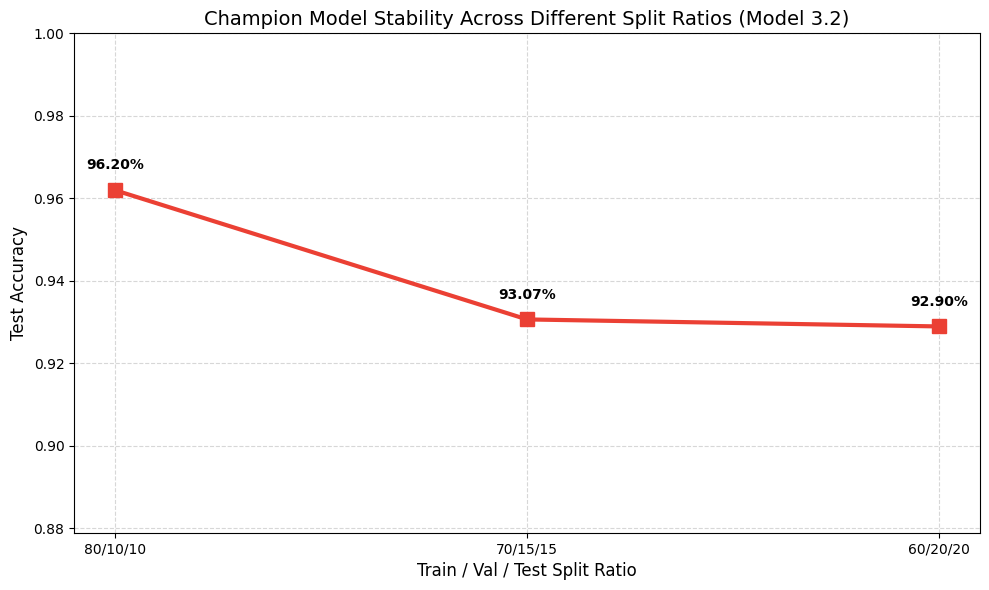

In [ ]:
import matplotlib.pyplot as plt

# 1. Define the labels
splits = ["80/10/10", "70/15/15", "60/20/20"]

# 2. Extract the live variables
# Note: 'results' comes from your Tournament cell,
# 'test_acc_70' and 'test_acc_60' from the split investigation cells.
test_accuracies = [
    results["Model 3.2 (MobileNet Dropout)"][1],
    test_acc_70,
    test_acc_60
]

# 3. Create the visualization
plt.figure(figsize=(10, 6))
plt.plot(splits, test_accuracies, marker='s', linestyle='-', color='#eb4034', linewidth=3, markersize=10)

# Dynamic annotations to show exact percentages above the markers
for i, acc in enumerate(test_accuracies):
    plt.annotate(f"{acc:.2%}", (splits[i], test_accuracies[i]),
                 textcoords="offset points", xytext=(0,15), ha='center', fontweight='bold')

plt.title('Champion Model Stability Across Different Split Ratios (Model 3.2)', fontsize=14)
plt.xlabel('Train / Val / Test Split Ratio', fontsize=12)
plt.ylabel('Test Accuracy', fontsize=12)

# Dynamically set Y-axis to focus on the performance range
plt.ylim(min(test_accuracies) - 0.05, 1.0)

plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Interactive Testing of the Model *3.2*

Google Colab detected. Opening file uploader...


Saving cat.jpg to cat.jpg


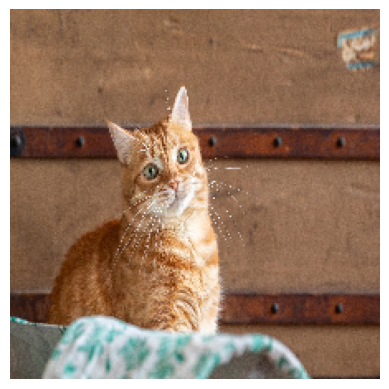

Prediction: It's a CAT! (Confidence: 99.17%)



In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

image_paths = []

# Dynamic Environment Detection (Works on both Colab and Jupyter)
try:
    from google.colab import files
    print("Google Colab detected. Opening file uploader...")
    uploaded = files.upload()
    image_paths = ['/content/' + fn for fn in uploaded.keys()]
except ModuleNotFoundError:
    print("Local Jupyter environment detected.")
    filename = input("Enter the filename of your test image (e.g., cat.jpg): ")
    if os.path.exists(filename):
        image_paths = [filename]
    else:
        print(f" Error: '{filename}' not found in the current directory.")

# Run inference on the selected image(s)
for path in image_paths:
    img = image.load_img(path, target_size=(224, 224))

    # Display the image
    plt.imshow(img)
    plt.axis('off')
    plt.show()

    # Process image for prediction
    x = image.img_to_array(img)
    x = np.expand_dims(x, axis=0)

    # Predict using the champion model (Model 3.2)
    prediction = model_mob_v2.predict(x, verbose=0)[0][0]

    try:
        class_names = train_ds.class_names
    except:
        class_names = ['cat', 'dog']

    if prediction < 0.5:
        confidence = (1 - prediction) * 100
        print(f"Prediction: It's a {class_names[0].upper()}! (Confidence: {confidence:.2f}%)\n")
    else:
        confidence = prediction * 100
        print(f"Prediction: It's a {class_names[1].upper()}! (Confidence: {confidence:.2f}%)\n")